# Notebook 05 — Transform-Domain (DCT) Compressed Sensing

Notebook 04 showed that in the **pixel domain**, all Gaussian-sparse-prior methods collapse on Fashion-MNIST at measurement ratio 0.25 (ISTA/FISTA/StepThresholdISTA ≈ −1.2 dB, ALISTA −0.9 dB, HyperLISTA −0.3 dB), while the data-driven LISTA-L2 still reconstructs well (−13.7 dB, SSIM 0.82).

This notebook tests whether that collapse is a **domain problem rather than an algorithm problem**. We keep the *exact same physical measurements*

$$
y = A x + \epsilon, \qquad x \in [0,1]^{784},
$$

(same seed, same sensing matrix $A$, same splits as Notebook 04) but perform recovery in the 2D-DCT domain. With $\alpha = \Psi x$ the DCT coefficients of the image and $\Psi$ the orthonormal 2D-DCT basis, the measurements satisfy

$$
y = A\Psi^{\top} \alpha \equiv D \alpha ,
$$

so every model receives the **effective dictionary** $D = A\Psi^{\top}$ in place of $A$, recovers $\hat{\alpha}$, and the image is reconstructed as $\hat{x} = \Psi^{\top}\hat{\alpha}$ (the inverse DCT).

Because $\Psi$ is orthonormal:

- $\|D\|_2 = \|A\|_2$ exactly, so every model's spectral-norm-based step size stays correct without renormalizing $D$'s columns (their norms stay ≈ 1);
- NMSE measured on $\alpha$ equals NMSE on the (unclamped) reconstructed pixels, so results are directly comparable with Notebook 04.

We compare the same six models: ISTA, FISTA, StepThresholdISTA, LISTA-L2, ALISTA, and HyperLISTA.

In [1]:
import sys, os, json, time
sys.path.insert(0, os.path.abspath(".."))

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data.image_loader import build_transform_cs_dataloaders
from src.operators.dct_operators import dct2_flat, idct2_flat
from src.models.ista import ISTA
from src.models.fista import FISTA
from src.models.learned_ista import StepThresholdISTA
from src.models.lista import LISTA
from src.models.alista import ALISTA
from src.models.hyperlista import HyperLISTA

from src.training.trainer import train
from src.training.tuner import tune_hyperlista
from src.evaluation.metrics import psnr, ssim_batch, evaluate_model

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

print(f"Device: {device}")

Device: cuda


In [2]:
# ============================================================
# Experiment configuration
# ============================================================

DATASET_NAME = "fashionmnist"          # "mnist" or "fashionmnist"
MEASUREMENT_RATIO = 0.25         # e.g. 0.25 or 0.5
SIGMA = 0.0
BATCH_SIZE = 256
N_VAL = 5000
K = 16
LAM = 0.01

RUN_ALISTA = True
RUN_HYPERLISTA = True

DATA_ROOT = "../data"

def make_tag(value):
    """Convert numeric values to compact path-safe tags."""
    if isinstance(value, float):
        return str(value).replace(".", "")
    return str(value)

ratio_tag = make_tag(MEASUREMENT_RATIO)
sigma_tag = make_tag(SIGMA)

EXPERIMENT_ID = (
    f"{DATASET_NAME}"
    f"_dct"
    f"_ratio{ratio_tag}"
    f"_sigma{sigma_tag}"
    f"_K{K}"
    f"_lamsweep"
    f"_seed{SEED}"
)

RESULTS_DIR = os.path.join("../results/notebook_05", EXPERIMENT_ID)
CKPT_DIR = os.path.join(RESULTS_DIR, "checkpoints")
FIG_DIR = os.path.join(RESULTS_DIR, "figures")
TABLE_DIR = os.path.join(RESULTS_DIR, "tables")

os.makedirs(CKPT_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(TABLE_DIR, exist_ok=True)

config = {
    "dataset_name": DATASET_NAME,
    "domain": "dct",
    "measurement_ratio": MEASUREMENT_RATIO,
    "sigma": SIGMA,
    "batch_size": BATCH_SIZE,
    "n_val": N_VAL,
    "K": K,
    "initial_lambda": LAM,
    "lambda": None,
    "seed": SEED,
    "run_alista": RUN_ALISTA,
    "run_hyperlista": RUN_HYPERLISTA,
}

with open(os.path.join(RESULTS_DIR, "config.json"), "w") as f:
    json.dump(config, f, indent=2)

print(f"Experiment ID: {EXPERIMENT_ID}")
print(f"Results directory: {RESULTS_DIR}")

Experiment ID: fashionmnist_dct_ratio025_sigma00_K16_lamsweep_seed42
Results directory: ../results/notebook_05/fashionmnist_dct_ratio025_sigma00_K16_lamsweep_seed42


## 1. Transform-Domain Setup and Sanity Checks

The loader reproduces Notebook 04's RNG call order exactly, so for a given seed and device the sensing matrix $A$, the train/val/test splits, and the measurements $y = Ax$ are bit-identical to the pixel-domain experiment. Only the recovery variable changes: models now operate on $D = A\Psi^{\top}$ and predict DCT coefficients.

Before training anything we verify the three properties the formulation relies on:

1. $\sigma_{\max}(D) = \sigma_{\max}(A)$ (orthonormal $\Psi$ preserves the spectral norm, hence step sizes);
2. $y = D\alpha$ holds on real data (measurement consistency);
3. NMSE on $\alpha$ equals NMSE on unclamped reconstructed pixels (metric comparability with Notebook 04);

plus the project's standard smoke test: an untrained LISTA initialized from $D$ must match classical ISTA on $D$ exactly.

In [3]:
A, D, Psi, train_loader, val_loader, test_loader = build_transform_cs_dataloaders(
    dataset_name=DATASET_NAME,
    measurement_ratio=MEASUREMENT_RATIO,
    sigma=SIGMA,
    batch_size=BATCH_SIZE,
    data_root=DATA_ROOT,
    device=device,
    seed=SEED,
    n_val=N_VAL,
)

torch.save(A.detach().cpu(), os.path.join(CKPT_DIR, "A.pt"))
torch.save(D.detach().cpu(), os.path.join(CKPT_DIR, "D.pt"))

d = D.shape[1]
m = D.shape[0]

print(f"Dataset: {DATASET_NAME} (DCT domain)")
print(f"A: {tuple(A.shape)}, D = A @ Psi.T: {tuple(D.shape)}")
print(f"m={m}, d={d}, measurement ratio={MEASUREMENT_RATIO}")
print(f"train samples: {len(train_loader.dataset)}")
print(f"val samples:   {len(val_loader.dataset)}")
print(f"test samples:  {len(test_loader.dataset)}")
print(f"K={K}, initial lambda={LAM}, sigma={SIGMA}")
print()

# ── Sanity check 1: spectral norm is preserved (step sizes stay correct) ──
smax_A = torch.linalg.svdvals(A)[0].item()
smax_D = torch.linalg.svdvals(D)[0].item()
assert abs(smax_D - smax_A) / smax_A < 1e-4, (smax_A, smax_D)
print(f"sigma_max(A) = {smax_A:.4f}, sigma_max(D) = {smax_D:.4f}  [equal, as expected]")

col_norms = D.norm(dim=0)
print(f"D column norms: min={col_norms.min():.3f}, "
      f"mean={col_norms.mean():.3f}, max={col_norms.max():.3f}  "
      f"[~1, so no renormalization needed]")

# ── Sanity check 2: measurement consistency y = D alpha ──
y_chk, alpha_chk, x_chk = next(iter(test_loader))
resid = (alpha_chk @ D.T - y_chk).abs().max().item()
assert resid < 1e-3, resid
print(f"max |D alpha - y| = {resid:.2e}  [measurement consistency holds]")

# ── Sanity check 3: NMSE on alpha == NMSE on unclamped pixels ──
def _nmse(a_hat, a_true):
    num = ((a_hat - a_true) ** 2).sum(dim=-1)
    den = (a_true ** 2).sum(dim=-1).clamp(min=1e-12)
    return (num / den).mean().item()

alpha_pert = alpha_chk + 0.1 * torch.randn_like(alpha_chk)
nmse_alpha = _nmse(alpha_pert, alpha_chk)
nmse_pixel = _nmse(idct2_flat(alpha_pert), x_chk)
assert abs(nmse_alpha - nmse_pixel) < 1e-5, (nmse_alpha, nmse_pixel)
print(f"NMSE(alpha) = {nmse_alpha:.6f}, NMSE(pixels) = {nmse_pixel:.6f}  [identical]")

# ── Sanity check 4: untrained LISTA on D == classical ISTA on D ──
with torch.no_grad():
    lista_chk = LISTA(D, n_layers=K, tied=False, lam=LAM).to(device)
    ista_chk = ISTA(D, lam=LAM, n_iter=K).to(device)
    y_dev = y_chk.to(device)
    diff = (lista_chk(y_dev) - ista_chk(y_dev)).abs().max().item()
assert diff < 1e-4, diff
print(f"max |untrained LISTA - ISTA| on D = {diff:.2e}  [smoke test passed]")
del lista_chk, ista_chk

Dataset: fashionmnist (DCT domain)
A: (196, 784), D = A @ Psi.T: (196, 784)
m=196, d=784, measurement ratio=0.25
train samples: 55000
val samples:   5000
test samples:  10000
K=16, initial lambda=0.01, sigma=0.0

sigma_max(A) = 2.9569, sigma_max(D) = 2.9570  [equal, as expected]
D column norms: min=0.857, mean=0.999, max=1.137  [~1, so no renormalization needed]
max |D alpha - y| = 4.77e-06  [measurement consistency holds]
NMSE(alpha) = 0.078913, NMSE(pixels) = 0.078913  [identical]


max |untrained LISTA - ISTA| on D = 1.24e-05  [smoke test passed]


## 2. Why the DCT Domain? Coefficient Decay

The pixel-domain experiments relied on images being *approximately* sparse in the pixel domain (many dark background pixels). That assumption is weak for Fashion-MNIST (~51% near-zero pixels, textured garments).

The DCT coefficients of natural images decay much faster: most of the energy concentrates in a few low-frequency coefficients. The plot below compares the mean sorted magnitude profile of the DCT coefficients $|\alpha|$ against the raw pixels $|x|$ — the DCT profile drops by orders of magnitude while the pixel profile stays flat. This is the compressibility that the sparse-recovery prior actually needs.

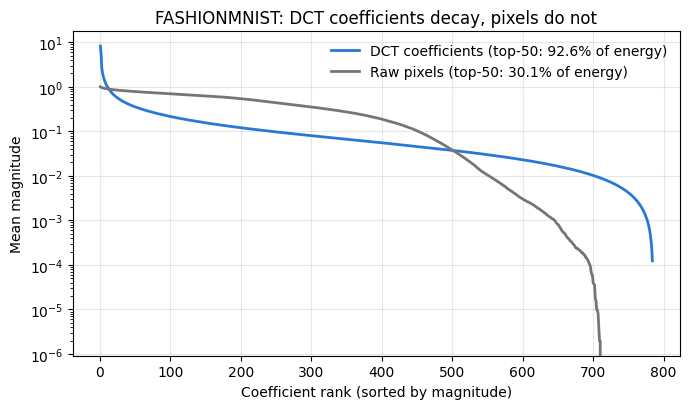

Top-50 DCT coefficients carry 92.6% of the energy
Top-50 pixels carry           30.1% of the energy
Saved figure to: ../results/notebook_05/fashionmnist_dct_ratio025_sigma00_K16_lamsweep_seed42/figures/dct_coefficient_decay.pdf


In [4]:
ds_train = train_loader.dataset
N_STAT = 2000
alpha_sample = ds_train.alpha[:N_STAT].detach().cpu()
x_sample = ds_train.images[:N_STAT].detach().cpu()

abs_alpha_sorted = alpha_sample.abs().sort(dim=1, descending=True).values
abs_x_sorted = x_sample.abs().sort(dim=1, descending=True).values

mean_alpha_profile = abs_alpha_sorted.mean(dim=0).numpy()
mean_x_profile = abs_x_sorted.mean(dim=0).numpy()

def topk_energy_fraction(sorted_abs, k):
    energy = sorted_abs ** 2
    return (energy[:, :k].sum(dim=1) / energy.sum(dim=1).clamp(min=1e-12)).mean().item()

TOP_K = 50
frac_alpha = topk_energy_fraction(abs_alpha_sorted, TOP_K)
frac_x = topk_energy_fraction(abs_x_sorted, TOP_K)

C_DCT = "#2a78d6"     # series color (validated categorical slot 1)
C_PIXEL = "#757575"   # neutral gray for the pixel-domain reference

fig, ax = plt.subplots(figsize=(7.0, 4.2))
ranks = np.arange(1, 785)
ax.plot(ranks, mean_alpha_profile, color=C_DCT, lw=2,
        label=f"DCT coefficients (top-{TOP_K}: {frac_alpha*100:.1f}% of energy)")
ax.plot(ranks, mean_x_profile, color=C_PIXEL, lw=2,
        label=f"Raw pixels (top-{TOP_K}: {frac_x*100:.1f}% of energy)")
ax.set_yscale("log")
ax.set_xlabel("Coefficient rank (sorted by magnitude)")
ax.set_ylabel("Mean magnitude")
ax.set_title(f"{DATASET_NAME.upper()}: DCT coefficients decay, pixels do not")
ax.grid(True, alpha=0.3)
ax.legend(frameon=False)
plt.tight_layout()

fig_path = os.path.join(FIG_DIR, "dct_coefficient_decay.pdf")
plt.savefig(fig_path, bbox_inches="tight")
plt.show()

print(f"Top-{TOP_K} DCT coefficients carry {frac_alpha*100:.1f}% of the energy")
print(f"Top-{TOP_K} pixels carry           {frac_x*100:.1f}% of the energy")
print(f"Saved figure to: {fig_path}")

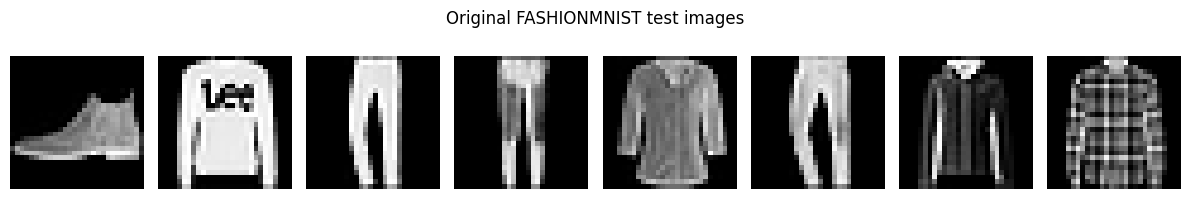

Saved figure to: ../results/notebook_05/fashionmnist_dct_ratio025_sigma00_K16_lamsweep_seed42/figures/original_fashionmnist_samples.pdf


In [5]:
# Fixed visualization batch (loader yields (y, alpha, x) triplets)
y_vis, alpha_vis, x_vis = next(iter(test_loader))
y_vis = y_vis.to(device)
alpha_vis = alpha_vis.to(device)
x_vis = x_vis.to(device)

N_SHOW = 8

plt.figure(figsize=(12, 2))

for i in range(N_SHOW):
    plt.subplot(1, N_SHOW, i + 1)
    plt.imshow(x_vis[i].detach().cpu().reshape(28, 28), cmap="gray")
    plt.axis("off")

plt.suptitle(f"Original {DATASET_NAME.upper()} test images")
plt.tight_layout()

fig_path = os.path.join(FIG_DIR, f"original_{DATASET_NAME}_samples.pdf")
plt.savefig(fig_path)
plt.show()

print(f"Saved figure to: {fig_path}")

## 3. Lambda Selection for Classical Baselines

As in Notebook 04, we sweep \(\lambda\) for ISTA and FISTA on the validation set before training any learned model.

The grid extends well *above* the pixel-domain sweep (which topped out at \(\lambda = 1\)): DCT coefficients are compressible with a dominant DC scale of ~8, and with only \(K=16\) iterations a large threshold that keeps just the dominant low-frequency coefficients is a strong strategy. A preliminary sweep confirmed that validation NMSE was still improving at \(\lambda = 1\), so the grid reaches up to \(\lambda = 30\) (threshold \(\theta = \lambda/L \approx 3.4\), comparable to the DC scale).

In [6]:
@torch.no_grad()
def final_nmse_db_on_loader(model, loader, device):
    model.eval()
    model.to(device)

    values = []

    for batch in loader:
        b, x_true = batch[0].to(device), batch[1].to(device)
        x_hat = model(b)

        num = ((x_hat - x_true) ** 2).sum(dim=-1)
        den = (x_true ** 2).sum(dim=-1).clamp(min=1e-12)
        nmse = (num / den).mean()
        values.append(10.0 * torch.log10(nmse.clamp(min=1e-30)).item())

    return float(np.mean(values))

In [7]:
LAMBDA_GRID = [0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1.0, 3.0, 10.0, 30.0]

lambda_sweep_rows = []

print(f"{'lambda':>10} {'ISTA val NMSE':>16} {'FISTA val NMSE':>16}")
print("-" * 46)

for lam in LAMBDA_GRID:
    ista_tmp = ISTA(D, lam=lam, n_iter=K)
    fista_tmp = FISTA(D, lam=lam, n_iter=K)

    ista_val = final_nmse_db_on_loader(ista_tmp, val_loader, device)
    fista_val = final_nmse_db_on_loader(fista_tmp, val_loader, device)

    lambda_sweep_rows.append({
        "lambda": lam,
        "ista_val_nmse_db": ista_val,
        "fista_val_nmse_db": fista_val,
    })

    print(f"{lam:>10.4g} {ista_val:>16.3f} {fista_val:>16.3f}")

lambda_sweep_df = pd.DataFrame(lambda_sweep_rows)
lambda_sweep_path = os.path.join(TABLE_DIR, "lambda_sweep.csv")
lambda_sweep_df.to_csv(lambda_sweep_path, index=False)

best_row = lambda_sweep_df.loc[
    lambda_sweep_df["fista_val_nmse_db"].idxmin()
]

LAM = float(best_row["lambda"])

config["lambda"] = LAM
config["selected_lambda"] = LAM
config["lambda_grid"] = LAMBDA_GRID
config["lambda_selection"] = "best FISTA validation NMSE over LAMBDA_GRID"

with open(os.path.join(RESULTS_DIR, "config.json"), "w") as f:
    json.dump(config, f, indent=2)

display(lambda_sweep_df)

print()
print(f"Selected lambda: {LAM}")
print(f"LAM used for the rest of the notebook: {LAM}")
print(f"Saved lambda sweep to: {lambda_sweep_path}")

    lambda    ISTA val NMSE   FISTA val NMSE
----------------------------------------------
     0.001           -1.135           -1.157


     0.003           -1.156           -1.218


      0.01           -1.226           -1.417
      0.03           -1.410           -1.907


       0.1           -1.941           -3.222


       0.3           -2.965           -5.394
         1           -3.964           -5.643


         3           -2.380           -2.933


        10           -0.084           -0.106


        30            0.000            0.000


,lambda,ista_val_nmse_db,fista_val_nmse_db
0,0.001,-1.135181,-1.156960
1,0.003,-1.155702,-1.218133
2,0.010,-1.225526,-1.417311
3,0.030,-1.409873,-1.907036
4,0.100,-1.941070,-3.222019
5,0.300,-2.964867,-5.393570
6,1.000,-3.964014,-5.642862
7,3.000,-2.379591,-2.932768
8,10.000,-0.084217,-0.105914
9,30.000,0.000000,0.000000



Selected lambda: 1.0
LAM used for the rest of the notebook: 1.0
Saved lambda sweep to: ../results/notebook_05/fashionmnist_dct_ratio025_sigma00_K16_lamsweep_seed42/tables/lambda_sweep.csv


## 4. Evaluation Helpers

Metrics follow Notebook 04's conventions exactly so the two experiments are directly comparable:

- **NMSE (dB)** on the predicted DCT coefficients $\hat{\alpha}$ — by orthonormality of $\Psi$ this equals the NMSE of the unclamped pixel reconstruction, i.e. the same quantity Notebook 04 reports;
- **PSNR** and **SSIM** on the reconstructed image $\hat{x} = \Psi^{\top}\hat{\alpha}$, clamped to $[0,1]$ (Notebook 04 also clamps before PSNR/SSIM);
- runtime and number of learned/tuned parameters.

In [8]:
results = {}
layer_curves = {}
histories = {}
reconstructions = {}


def safe_name(name):
    return name.lower().replace(" ", "_").replace("-", "_")


def nmse_db_batch(x_hat, x_true, eps=1e-12):
    num = ((x_hat - x_true) ** 2).sum(dim=-1)
    den = (x_true ** 2).sum(dim=-1).clamp(min=eps)
    nmse = (num / den).mean()
    return 10.0 * torch.log10(nmse.clamp(min=1e-30)).item()


@torch.no_grad()
def layerwise_nmse_db(model, loader, device):
    model.eval()
    model.to(device)

    sums = None
    n_batches = 0

    for batch in loader:
        b, x_true = batch[0].to(device), batch[1].to(device)
        iterates = model(b, return_all=True)

        if sums is None:
            sums = [0.0 for _ in iterates]

        for k, x_hat_k in enumerate(iterates):
            sums[k] += nmse_db_batch(x_hat_k, x_true)

        n_batches += 1

    return [v / n_batches for v in sums]


@torch.no_grad()
def image_quality_metrics(model, loader, device):
    """PSNR/SSIM on clamped IDCT reconstructions vs the original pixels."""
    model.eval()
    model.to(device)

    psnr_vals = []
    ssim_vals = []

    for batch in loader:
        y, _, x_true = [t.to(device) for t in batch]

        alpha_hat = model(y)
        x_hat_img = idct2_flat(alpha_hat).clamp(0.0, 1.0)

        psnr_vals.append(psnr(x_hat_img, x_true, max_val=1.0))
        ssim_vals.append(ssim_batch(x_hat_img, x_true, H=28, W=28, data_range=1.0))

    return {
        "psnr": float(np.mean(psnr_vals)),
        "ssim": float(np.mean(ssim_vals)),
    }


@torch.no_grad()
def store_visual_reconstructions(name, model):
    model.eval()
    model.to(device)

    alpha_hat = model(y_vis)
    x_hat = idct2_flat(alpha_hat).clamp(0.0, 1.0)
    reconstructions[name] = x_hat[:N_SHOW].detach().cpu()


def evaluate_and_store(name, model, training_type, save_checkpoint=False):
    model.to(device)

    metrics = evaluate_model(
        model,
        test_loader,
        device=device,
        image_mode=False,   # NMSE on alpha == pixel NMSE (orthonormal Psi)
        measure_time=True,
    )
    image_metrics = image_quality_metrics(model, test_loader, device)
    metrics.update(image_metrics)

    results[name] = {
        "nmse_db": metrics["nmse_db"],
        "psnr": metrics["psnr"],
        "ssim": metrics["ssim"],
        "runtime_ms": metrics["runtime_ms"],
        "n_params": metrics["n_params"],
        "training": training_type,
    }

    layer_curves[name] = layerwise_nmse_db(model, test_loader, device)
    store_visual_reconstructions(name, model)

    if save_checkpoint:
        torch.save(
            model.state_dict(),
            os.path.join(CKPT_DIR, f"{safe_name(name)}.pt"),
        )

    print(
        f"{name:<22} "
        f"NMSE={metrics['nmse_db']:>8.3f} dB | "
        f"PSNR={metrics['psnr']:>6.2f} | "
        f"SSIM={metrics['ssim']:>6.3f} | "
        f"params={metrics['n_params']:>10} | "
        f"runtime={metrics['runtime_ms']:>8.3f} ms"
    )

## 5. Classical Baselines: ISTA and FISTA

ISTA and FISTA run on the effective dictionary $D$ with the validation-selected $\lambda$.

In the pixel domain both stalled around −1.2 dB. If the DCT domain restores the sparse prior, the same untrained algorithms should improve markedly.

In [9]:
ista = ISTA(D, lam=LAM, n_iter=K)
fista = FISTA(D, lam=LAM, n_iter=K)

print("Classical DCT-domain baselines:")
evaluate_and_store("ISTA", ista, training_type="none")
evaluate_and_store("FISTA", fista, training_type="none")

Classical DCT-domain baselines:


ISTA                   NMSE=  -3.978 dB | PSNR= 11.35 | SSIM= 0.258 | params=         0 | runtime=   1.386 ms


FISTA                  NMSE=  -5.647 dB | PSNR= 13.67 | SSIM= 0.350 | params=         0 | runtime=   1.984 ms


## 6. Our ISTA-Derived Scalar Model: StepThresholdISTA

StepThresholdISTA keeps the ISTA correction direction $D^{\top}(y - D\alpha^k)$ but learns a per-layer step size and threshold (32 scalars total):

$$
\alpha^{k+1}
=
S_{\theta_k}
\left(
\alpha^k+\gamma_k D^{\top}(y-D\alpha^k)
\right).
$$

In the pixel domain the learned schedule could not beat classical ISTA. Here we test whether the scalar schedule becomes useful again once the recovery domain matches the sparse prior.

In [10]:
torch.manual_seed(SEED)

step_threshold_ista = StepThresholdISTA(D, n_layers=K, lam=LAM).to(device)

print("Training StepThresholdISTA")

t0 = time.time()

history = train(
    model=step_threshold_ista,
    train_loader=train_loader,
    val_loader=val_loader,
    n_epochs=50,
    lr=1e-2,
    weight_decay=1e-5,
    device=device,
    patience=10,
    intermediate_weight=0.0,
    verbose=True,
)

train_sec = time.time() - t0

histories["StepThresholdISTA"] = history

evaluate_and_store(
    name="StepThresholdISTA",
    model=step_threshold_ista,
    training_type=f"final loss ({train_sec / 60:.1f} min train)",
    save_checkpoint=True,
)

Training StepThresholdISTA


Training:   0%|          | 0/50 [00:00<?, ?epoch/s]

Training:   0%|          | 0/50 [00:01<?, ?epoch/s, lr=1.00e-02, train_loss=0.0451, val_nmse=-6.97 dB]

Training:   2%|▏         | 1/50 [00:01<00:59,  1.22s/epoch, lr=1.00e-02, train_loss=0.0451, val_nmse=-6.97 dB]

Training:   2%|▏         | 1/50 [00:02<00:59,  1.22s/epoch, lr=1.00e-02, train_loss=0.0322, val_nmse=-7.08 dB]

...

Training:  98%|█████████▊| 49/50 [00:52<00:01,  1.08s/epoch, lr=1.00e-02, train_loss=0.0266, val_nmse=-7.74 dB]

Training:  98%|█████████▊| 49/50 [00:53<00:01,  1.08s/epoch, lr=1.00e-02, train_loss=0.0266, val_nmse=-7.74 dB]

Training: 100%|██████████| 50/50 [00:53<00:00,  1.06s/epoch, lr=1.00e-02, train_loss=0.0266, val_nmse=-7.74 dB]

Training: 100%|██████████| 50/50 [00:53<00:00,  1.06s/epoch, lr=1.00e-02, train_loss=0.0266, val_nmse=-7.74 dB]

StepThresholdISTA      NMSE=  -7.750 dB | PSNR= 16.11 | SSIM= 0.522 | params=        32 | runtime=   1.466 ms


## 7. LISTA-L2 in the DCT Domain

LISTA learns full matrices in each unfolded layer and is initialized to exact ISTA on $D$:

$$
\alpha^{k+1}
=
S_{\theta_k}
\left(
W_y^k y + W_x^k \alpha^k
\right).
$$

LISTA-L2 was the only model that survived the pixel domain, so it serves as the ceiling here. The interesting question is not whether it still works (it should), but how much of its advantage over the structured models remains once the domain mismatch is removed.

In [11]:
torch.manual_seed(SEED)

lista_l2 = LISTA(D, n_layers=K, tied=False, lam=LAM).to(device)

print("Training LISTA-L2")

t0 = time.time()

history = train(
    model=lista_l2,
    train_loader=train_loader,
    val_loader=val_loader,
    n_epochs=50,
    lr=5e-4,
    weight_decay=0.0,
    device=device,
    patience=15,
    intermediate_weight=0.1,
    verbose=True,
)

train_sec = time.time() - t0

histories["LISTA-L2"] = history

evaluate_and_store(
    name="LISTA-L2",
    model=lista_l2,
    training_type=f"L2 intermediate ({train_sec / 60:.1f} min train)",
    save_checkpoint=True,
)

Training LISTA-L2


Training:   0%|          | 0/50 [00:00<?, ?epoch/s]

Training:   0%|          | 0/50 [00:02<?, ?epoch/s, lr=5.00e-04, train_loss=0.0176, val_nmse=-11.15 dB]

Training:   2%|▏         | 1/50 [00:02<01:57,  2.39s/epoch, lr=5.00e-04, train_loss=0.0176, val_nmse=-11.15 dB]

Training:   2%|▏         | 1/50 [00:04<01:57,  2.39s/epoch, lr=5.00e-04, train_loss=0.0117, val_nmse=-11.97 dB]

...

Training:  98%|█████████▊| 49/50 [01:59<00:02,  2.45s/epoch, lr=5.00e-04, train_loss=0.0048, val_nmse=-14.96 dB]

Training:  98%|█████████▊| 49/50 [02:01<00:02,  2.45s/epoch, lr=5.00e-04, train_loss=0.0048, val_nmse=-15.01 dB]

Training: 100%|██████████| 50/50 [02:01<00:00,  2.45s/epoch, lr=5.00e-04, train_loss=0.0048, val_nmse=-15.01 dB]

Training: 100%|██████████| 50/50 [02:01<00:00,  2.43s/epoch, lr=5.00e-04, train_loss=0.0048, val_nmse=-15.01 dB]

LISTA-L2               NMSE= -14.891 dB | PSNR= 23.74 | SSIM= 0.814 | params=  12293136 | runtime=   2.359 ms


## 8. ALISTA in the DCT Domain

ALISTA computes its correction matrix $W$ analytically from $D$ (by coherence minimization) and learns only per-layer step sizes and thresholds — 32 scalars.

In the pixel domain, ALISTA's support-selection mechanism actively erased valid image content. In the DCT domain the dominant low-frequency coefficients are exactly the kind of signal that support selection is designed to protect.

In [12]:
torch.manual_seed(SEED)

alista = ALISTA(D, n_layers=K, W_iters=2000).to(device)

print("Training ALISTA")

t0 = time.time()

history = train(
    model=alista,
    train_loader=train_loader,
    val_loader=val_loader,
    n_epochs=50,
    lr=5e-4,
    weight_decay=1e-5,
    device=device,
    patience=15,
    intermediate_weight=0.0,
    verbose=True,
)

train_sec = time.time() - t0

histories["ALISTA"] = history

evaluate_and_store(
    name="ALISTA",
    model=alista,
    training_type=f"analytic W + scalars ({train_sec / 60:.1f} min train)",
    save_checkpoint=True,
)

Training ALISTA


Training:   0%|          | 0/50 [00:00<?, ?epoch/s]

Training:   0%|          | 0/50 [00:02<?, ?epoch/s, lr=5.00e-04, train_loss=2545324.2227, val_nmse=56.34 dB]

Training:   2%|▏         | 1/50 [00:02<02:22,  2.90s/epoch, lr=5.00e-04, train_loss=2545324.2227, val_nmse=56.34 dB]

Training:   2%|▏         | 1/50 [00:05<02:22,  2.90s/epoch, lr=5.00e-04, train_loss=25810.1553, val_nmse=32.44 dB]  

...

Training:  98%|█████████▊| 49/50 [02:15<00:02,  2.72s/epoch, lr=5.00e-04, train_loss=0.0574, val_nmse=-5.03 dB]

Training:  98%|█████████▊| 49/50 [02:17<00:02,  2.72s/epoch, lr=5.00e-04, train_loss=0.0567, val_nmse=-5.06 dB]

Training: 100%|██████████| 50/50 [02:17<00:00,  2.74s/epoch, lr=5.00e-04, train_loss=0.0567, val_nmse=-5.06 dB]

Training: 100%|██████████| 50/50 [02:17<00:00,  2.76s/epoch, lr=5.00e-04, train_loss=0.0567, val_nmse=-5.06 dB]

ALISTA                 NMSE=  -5.083 dB | PSNR= 13.08 | SSIM= 0.395 | params=        32 | runtime=   4.391 ms


## 9. HyperLISTA in the DCT Domain

HyperLISTA reduces the entire model to three tuned scalars $(c_1, c_2, c_3)$. In the pixel domain the grid search pushed $c_3$ far below its synthetic-data range and still landed at −0.27 dB — the clearest symptom of the model mismatch.

The search ranges here are sized to the DCT coefficient statistics (the threshold rule $\theta^{(k)} = c_1\,\mu\,\|D^{+}(D\alpha - y)\|_1$ must span thresholds from ~0.05 up to the DC scale ~8, and $c_3$ spans "support selection off" up to tens of protected coefficients).

In [13]:
torch.manual_seed(SEED)

hyperlista = HyperLISTA(D, n_layers=K, W_iters=2000).to(device)

print("Tuning HyperLISTA")

t0 = time.time()

best_hparams = tune_hyperlista(
    model=hyperlista,
    val_loader=val_loader,
    device=device,
    coarse_points=6,
    fine_points=7,
    coarse_batches=4,
    fine_batches=8,
    c1_range=(1e-3, 0.3),
    c2_range=(1e-4, 0.05),
    c3_range=(0.01, 100.0),
    verbose=True,
)

tune_sec = time.time() - t0

histories["HyperLISTA"] = best_hparams

with open(os.path.join(CKPT_DIR, "hyperlista_hparams.json"), "w") as f:
    json.dump(best_hparams, f, indent=2)

evaluate_and_store(
    name="HyperLISTA",
    model=hyperlista,
    training_type=f"grid-tuned hparams ({tune_sec / 60:.1f} min tune)",
    save_checkpoint=False,
)

print("Best HyperLISTA hyperparameters:")
print(best_hparams)

Tuning HyperLISTA
=== Stage 1: Coarse grid search ===


Coarse grid:   0%|          | 0/216 [00:00<?, ?it/s]

Coarse grid:   0%|          | 0/216 [00:00<?, ?it/s, best_nmse=145.67 dB]

Coarse grid:   0%|          | 0/216 [00:00<?, ?it/s, best_nmse=145.67 dB]

Coarse grid:   0%|          | 0/216 [00:00<?, ?it/s, best_nmse=145.67 dB]

...

Coarse grid:  99%|█████████▉| 341/343 [00:16<00:00, 20.97it/s, best_nmse=-7.72 dB]

Coarse grid:  99%|█████████▉| 341/343 [00:16<00:00, 20.97it/s, best_nmse=-7.72 dB]

Coarse grid: 100%|██████████| 343/343 [00:16<00:00, 20.28it/s, best_nmse=-7.72 dB]

Fine best:   c1=0.0306, c2=0.0100, c3=2.5119  NMSE=-7.72 dB  (16.9s)


HyperLISTA             NMSE=  -7.703 dB | PSNR= 16.17 | SSIM= 0.522 | params=         3 | runtime=   6.500 ms
Best HyperLISTA hyperparameters:
{'c1': 0.030638870628004047, 'c2': 0.010003122452653657, 'c3': 2.511886431509582, 'nmse_db': -7.716563194990158}


## 10. Final Summary

The table below summarizes reconstruction quality, image quality, model size, and runtime for the DCT-domain experiment.

In [14]:
display_order = [
    "ISTA",
    "FISTA",
    "StepThresholdISTA",
    "LISTA-L2",
    "ALISTA",
    "HyperLISTA",
]

summary_rows = []

print(
    f"{'Model':<22} "
    f"{'NMSE (dB)':>12} "
    f"{'PSNR':>8} "
    f"{'SSIM':>8} "
    f"{'# Params':>12} "
    f"{'Runtime (ms)':>14} "
    f"{'Training':>32}"
)
print("-" * 116)

for name in display_order:
    if name not in results:
        continue

    r = results[name]

    print(
        f"{name:<22} "
        f"{r['nmse_db']:>12.3f} "
        f"{r['psnr']:>8.2f} "
        f"{r['ssim']:>8.3f} "
        f"{r['n_params']:>12} "
        f"{r['runtime_ms']:>14.3f} "
        f"{r['training']:>32}"
    )

    summary_rows.append({
        "model": name,
        "nmse_db": r["nmse_db"],
        "psnr": r["psnr"],
        "ssim": r["ssim"],
        "n_params": r["n_params"],
        "runtime_ms": r["runtime_ms"],
        "training": r["training"],
    })

summary_df = pd.DataFrame(summary_rows)

summary_path = os.path.join(TABLE_DIR, "summary.csv")
summary_df.to_csv(summary_path, index=False)

display(summary_df)
print(f"Saved summary to: {summary_path}")

Model                     NMSE (dB)     PSNR     SSIM     # Params   Runtime (ms)                         Training
--------------------------------------------------------------------------------------------------------------------
ISTA                         -3.978    11.35    0.258            0          1.386                             none
FISTA                        -5.647    13.67    0.350            0          1.984                             none
StepThresholdISTA            -7.750    16.11    0.522           32          1.466       final loss (0.9 min train)
LISTA-L2                    -14.891    23.74    0.814     12293136          2.359  L2 intermediate (2.0 min train)
ALISTA                       -5.083    13.08    0.395           32          4.391 analytic W + scalars (2.3 min train)
HyperLISTA                   -7.703    16.17    0.522            3          6.500 grid-tuned hparams (0.4 min tune)


,model,nmse_db,psnr,ssim,n_params,runtime_ms,training
0,ISTA,-3.978006,11.346988,0.258392,0,1.386432,none
1,FISTA,-5.647229,13.669736,0.350028,0,1.984438,none
2,StepThresholdISTA,-7.749711,16.107757,0.521547,32,1.466417,final loss (0.9 min train)
3,LISTA-L2,-14.890969,23.742200,0.814367,12293136,2.358833,L2 intermediate (2.0 min train)
4,ALISTA,-5.083208,13.077803,0.395407,32,4.391284,analytic W + scalars (2.3 min train)
5,HyperLISTA,-7.703098,16.172696,0.521835,3,6.500457,grid-tuned hparams (0.4 min tune)


Saved summary to: ../results/notebook_05/fashionmnist_dct_ratio025_sigma00_K16_lamsweep_seed42/tables/summary.csv


## 11. Visual Reconstruction Comparison

Same test examples across all models, reconstructed via $\hat{x} = \Psi^{\top}\hat{\alpha}$ and clamped to $[0,1]$.

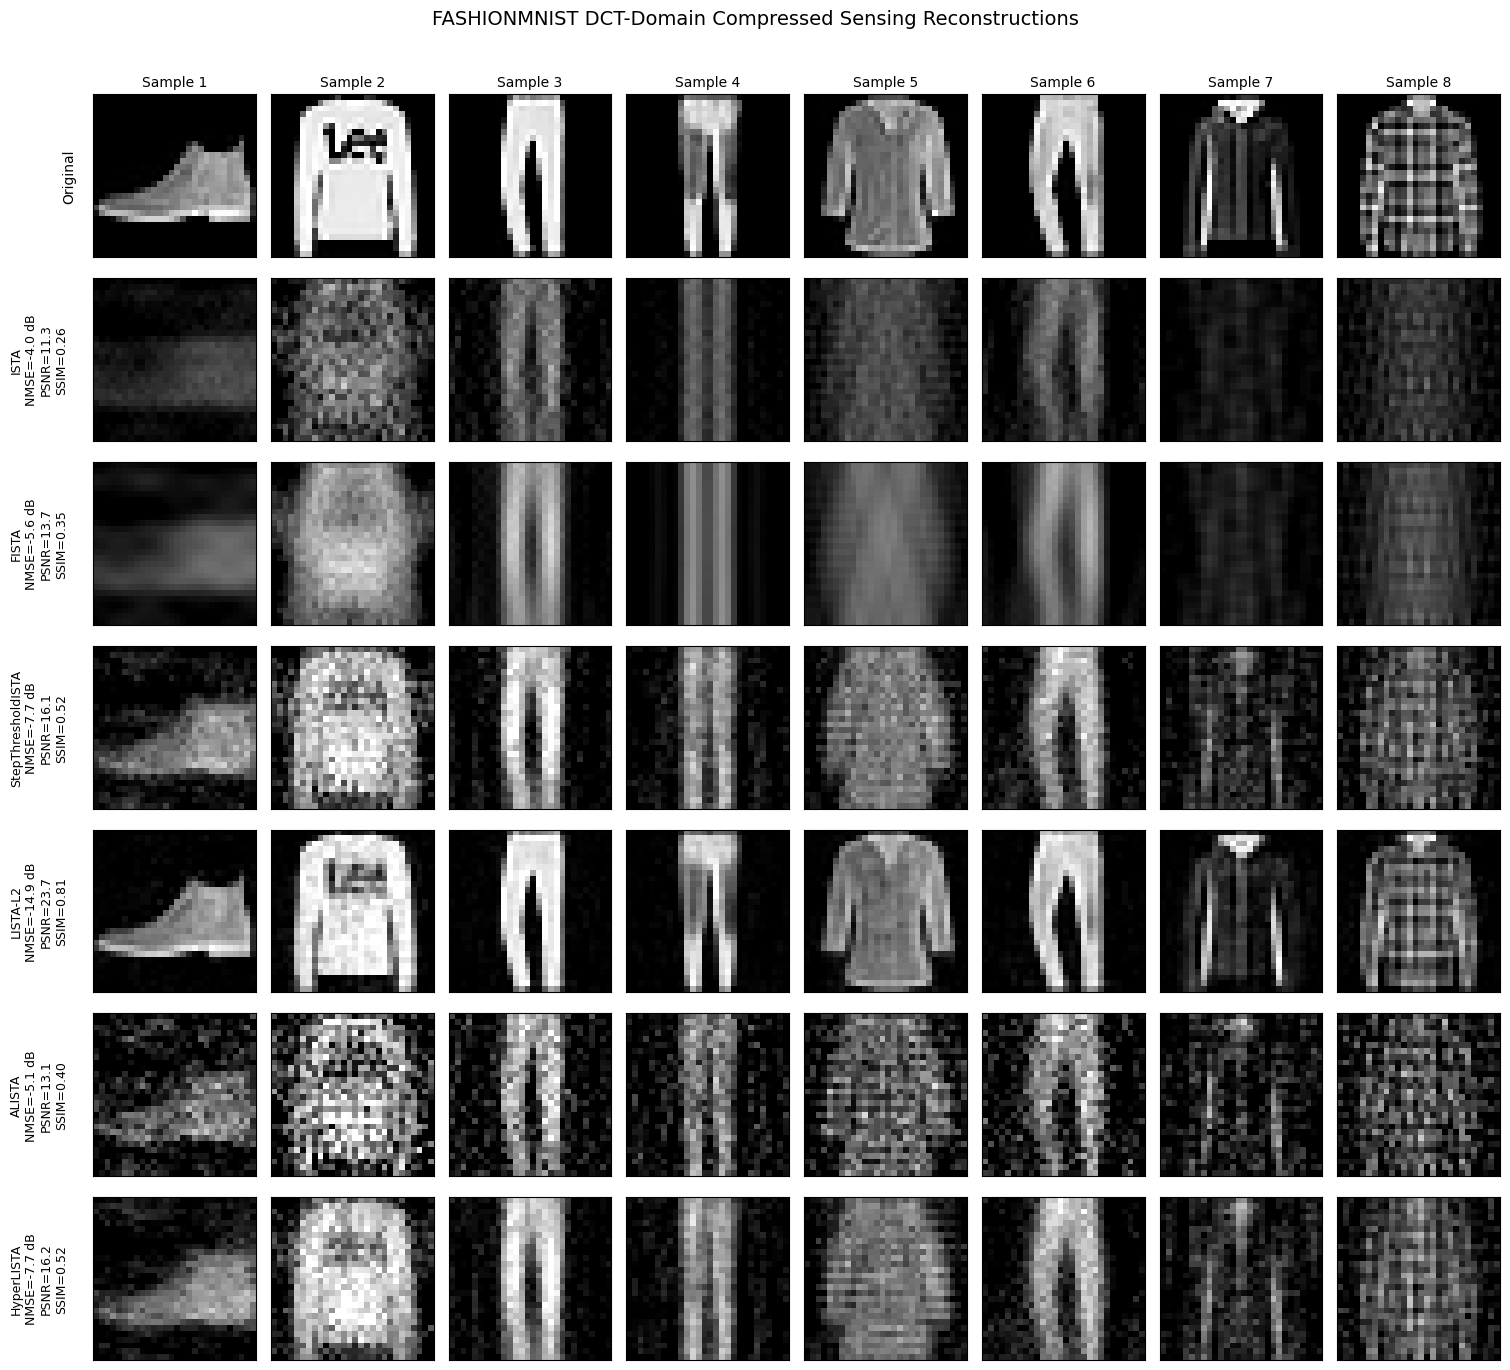

Saved figure to: ../results/notebook_05/fashionmnist_dct_ratio025_sigma00_K16_lamsweep_seed42/figures/fashionmnist_dct_reconstruction_grid.pdf


In [15]:
plot_models = [
    "ISTA",
    "FISTA",
    "StepThresholdISTA",
    "LISTA-L2",
    "ALISTA",
    "HyperLISTA",
]

n_rows = 1 + len(plot_models)
n_cols = N_SHOW

fig, axes = plt.subplots(n_rows, n_cols, figsize=(1.9 * n_cols, 2.0 * n_rows))

# Make sure axes is always 2D
if n_rows == 1:
    axes = np.expand_dims(axes, axis=0)
if n_cols == 1:
    axes = np.expand_dims(axes, axis=1)

# Column titles
for j in range(n_cols):
    axes[0, j].set_title(f"Sample {j+1}", fontsize=10)

# First row: original images
for j in range(n_cols):
    ax = axes[0, j]
    ax.imshow(x_vis[j].detach().cpu().reshape(28, 28), cmap="gray", vmin=0, vmax=1)
    ax.set_xticks([])
    ax.set_yticks([])
    if j == 0:
        ax.set_ylabel("Original", fontsize=10, rotation=90, labelpad=12)

# Reconstruction rows
for i, name in enumerate(plot_models, start=1):
    if name not in reconstructions:
        continue

    x_hat = reconstructions[name]

    nmse = results[name]["nmse_db"]
    psnr_val = results[name]["psnr"]
    ssim_val = results[name]["ssim"]
    row_label = f"{name}\nNMSE={nmse:.1f} dB\nPSNR={psnr_val:.1f}\nSSIM={ssim_val:.2f}"

    for j in range(n_cols):
        ax = axes[i, j]
        ax.imshow(x_hat[j].reshape(28, 28), cmap="gray", vmin=0, vmax=1)
        ax.set_xticks([])
        ax.set_yticks([])
        if j == 0:
            ax.set_ylabel(row_label, fontsize=9, rotation=90, labelpad=18)

fig.suptitle(
    f"{DATASET_NAME.upper()} DCT-Domain Compressed Sensing Reconstructions",
    fontsize=14,
)
plt.tight_layout(rect=[0, 0, 1, 0.97])

fig_path = os.path.join(FIG_DIR, f"{DATASET_NAME}_dct_reconstruction_grid.pdf")
plt.savefig(fig_path, bbox_inches="tight")
plt.show()

print(f"Saved figure to: {fig_path}")

## 12. Pixel Domain vs. DCT Domain

The direct comparison with Notebook 04: same measurements, same models, only the recovery domain differs.

Pixel-domain baseline values below were taken from the Notebook 04 runs (SSIM for all four dataset/ratio cells from the robustness heatmap; NMSE was archived only for the Fashion-MNIST ratio-0.25 cell, reported in the project report). The Notebook 04 summary CSVs are gitignored, hence the hardcoded fallback.

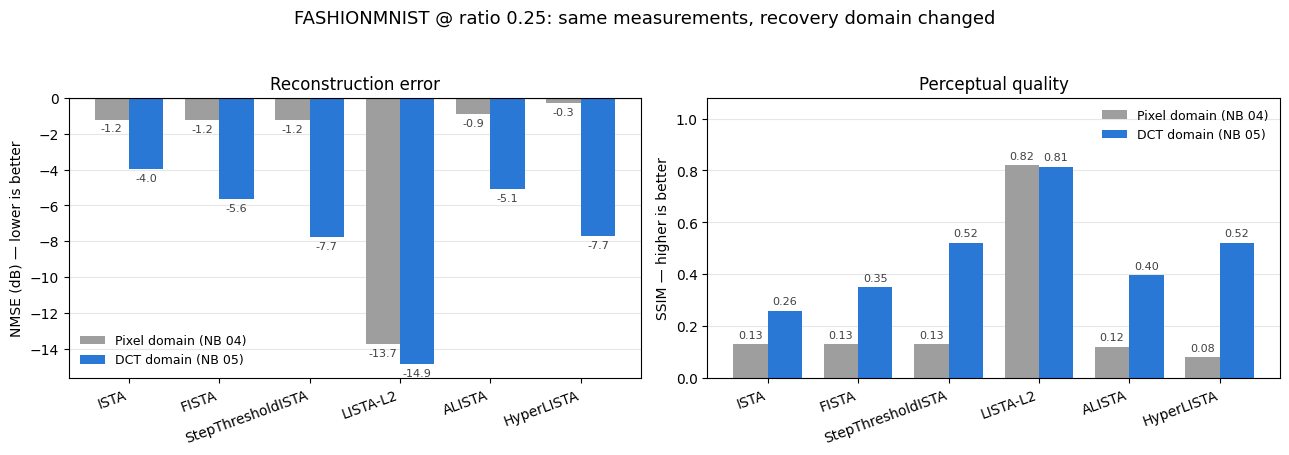

Saved figure to: ../results/notebook_05/fashionmnist_dct_ratio025_sigma00_K16_lamsweep_seed42/figures/pixel_vs_dct_comparison.pdf


In [16]:
# Pixel-domain baselines from Notebook 04.
# SSIM: read from presentation/assets/figures/ssim_heatmap.png (all four cells).
# NMSE (dB): only the fashionmnist/0.25 cell was archived (report Table 2).
PIXEL_BASELINE = {
    ("fashionmnist", 0.25): {
        "nmse_db": {"ISTA": -1.205, "FISTA": -1.210, "StepThresholdISTA": -1.209,
                    "LISTA-L2": -13.748, "ALISTA": -0.881, "HyperLISTA": -0.270},
        "ssim": {"ISTA": 0.13, "FISTA": 0.13, "StepThresholdISTA": 0.13,
                 "LISTA-L2": 0.82, "ALISTA": 0.12, "HyperLISTA": 0.08},
    },
    ("fashionmnist", 0.5): {
        "ssim": {"ISTA": 0.30, "FISTA": 0.33, "StepThresholdISTA": 0.33,
                 "LISTA-L2": 0.88, "ALISTA": 0.31, "HyperLISTA": 0.34},
    },
    ("mnist", 0.25): {
        "ssim": {"ISTA": 0.18, "FISTA": 0.21, "StepThresholdISTA": 0.22,
                 "LISTA-L2": 0.98, "ALISTA": 0.23, "HyperLISTA": 0.23},
    },
    ("mnist", 0.5): {
        "ssim": {"ISTA": 0.43, "FISTA": 0.59, "StepThresholdISTA": 0.74,
                 "LISTA-L2": 0.99, "ALISTA": 0.82, "HyperLISTA": 0.81},
    },
}

baseline = PIXEL_BASELINE.get((DATASET_NAME, MEASUREMENT_RATIO), {})
pixel_ssim = baseline.get("ssim", {})
pixel_nmse = baseline.get("nmse_db", {})

if not pixel_ssim:
    print(f"Warning: no pixel-domain baseline recorded for "
          f"({DATASET_NAME}, {MEASUREMENT_RATIO}); plotting DCT bars only.")

model_names = [n for n in display_order if n in results]
xpos = np.arange(len(model_names))
BAR_W = 0.38

C_DCT = "#2a78d6"
C_PIXEL = "#9e9e9e"

fig, (ax_nmse, ax_ssim) = plt.subplots(1, 2, figsize=(13, 4.6))

def _label_bars(ax, bars, fmt):
    for bar in bars:
        h = bar.get_height()
        va = "bottom" if h >= 0 else "top"
        offset = 0.5 if h >= 0 else -0.5
        ax.annotate(fmt.format(h),
                    (bar.get_x() + bar.get_width() / 2, h),
                    textcoords="offset points", xytext=(0, 3 if h >= 0 else -3),
                    ha="center", va=va, fontsize=8, color="#404040")

# ── NMSE panel (lower is better) ──
dct_nmse_vals = [results[n]["nmse_db"] for n in model_names]
if pixel_nmse:
    bars_p = ax_nmse.bar(xpos - BAR_W / 2, [pixel_nmse[n] for n in model_names],
                         BAR_W, color=C_PIXEL, label="Pixel domain (NB 04)")
    bars_d = ax_nmse.bar(xpos + BAR_W / 2, dct_nmse_vals,
                         BAR_W, color=C_DCT, label="DCT domain (NB 05)")
    _label_bars(ax_nmse, bars_p, "{:.1f}")
else:
    bars_d = ax_nmse.bar(xpos, dct_nmse_vals, BAR_W, color=C_DCT,
                         label="DCT domain (NB 05)")
_label_bars(ax_nmse, bars_d, "{:.1f}")

ax_nmse.set_ylabel("NMSE (dB) — lower is better")
ax_nmse.set_title("Reconstruction error")
ax_nmse.axhline(0.0, color="#404040", lw=0.8)

# ── SSIM panel (higher is better) ──
dct_ssim_vals = [results[n]["ssim"] for n in model_names]
if pixel_ssim:
    bars_p = ax_ssim.bar(xpos - BAR_W / 2, [pixel_ssim[n] for n in model_names],
                         BAR_W, color=C_PIXEL, label="Pixel domain (NB 04)")
    bars_d = ax_ssim.bar(xpos + BAR_W / 2, dct_ssim_vals,
                         BAR_W, color=C_DCT, label="DCT domain (NB 05)")
    _label_bars(ax_ssim, bars_p, "{:.2f}")
else:
    bars_d = ax_ssim.bar(xpos, dct_ssim_vals, BAR_W, color=C_DCT,
                         label="DCT domain (NB 05)")
_label_bars(ax_ssim, bars_d, "{:.2f}")

ax_ssim.set_ylabel("SSIM — higher is better")
ax_ssim.set_title("Perceptual quality")
ax_ssim.set_ylim(0, 1.08)

for ax in (ax_nmse, ax_ssim):
    ax.set_xticks(xpos)
    ax.set_xticklabels(model_names, rotation=20, ha="right")
    ax.grid(True, axis="y", alpha=0.3)
    ax.set_axisbelow(True)
    ax.legend(frameon=False, fontsize=9)

fig.suptitle(
    f"{DATASET_NAME.upper()} @ ratio {MEASUREMENT_RATIO}: "
    f"same measurements, recovery domain changed",
    fontsize=13,
)
plt.tight_layout(rect=[0, 0, 1, 0.94])

fig_path = os.path.join(FIG_DIR, "pixel_vs_dct_comparison.pdf")
plt.savefig(fig_path, bbox_inches="tight")
plt.show()

print(f"Saved figure to: {fig_path}")

## Discussion and Takeaways

This experiment isolates the role of the signal model in the Part B failure: the measurements, the sensing matrix, the architectures, and the training procedures are identical to Notebook 04 — only the domain in which sparsity is assumed has changed.

Running all four $\{$MNIST, Fashion-MNIST$\} \times \{0.25, 0.5\}$ cells gives a two-sided answer (SSIM, pixel $\to$ DCT):

| Cell | ISTA | FISTA | StepThr | LISTA-L2 | ALISTA | HyperLISTA |
|---|---|---|---|---|---|---|
| FMNIST @ 0.25 | 0.13 → **0.26** | 0.13 → **0.35** | 0.13 → **0.52** | 0.82 → 0.81 | 0.12 → **0.40** | 0.08 → **0.52** |
| FMNIST @ 0.5 | 0.30 → **0.45** | 0.33 → **0.57** | 0.33 → **0.68** | 0.88 → 0.82 | 0.31 → **0.69** | 0.34 → **0.71** |
| MNIST @ 0.25 | 0.18 → **0.22** | 0.21 → **0.31** | 0.22 → **0.43** | 0.98 → 0.88 | 0.23 → **0.37** | 0.23 → **0.43** |
| MNIST @ 0.5 | 0.43 → 0.45 | 0.59 → 0.57 | 0.74 → 0.65 | 0.99 → 0.85 | 0.82 → 0.66 | 0.81 → 0.66 |

**1. The Fashion-MNIST collapse was a domain problem, not an algorithm problem.** On the cell that broke every structured model (FMNIST @ 0.25), the same measurements re-expressed over $D = A\Psi^{\top}$ lift HyperLISTA from dead last (−0.27 dB, SSIM 0.085) to −7.70 dB / SSIM 0.52 with its 3 scalars — now beating classical ISTA/FISTA and matching StepThresholdISTA. At ratio 0.5, HyperLISTA becomes the *best* structured method (−11.4 dB, SSIM 0.71). The tuned $c_3$ returns to a healthy support-selection range (2.5–15.8 vs 0.17 in the pixel domain) and grows with the measurement ratio, exactly as the theory intends.

**2. The transform is not a free lunch — the domain must match the data.** On MNIST @ 0.5, where the pixel domain was already a *good* sparse domain (~78% exact zeros, and pen strokes are more localized in pixels than in frequency), moving to DCT *hurts* the structured learners (ALISTA 0.82 → 0.66, HyperLISTA 0.81 → 0.66). The same mechanism works in both directions: sparse recovery succeeds in whichever domain the signal is actually sparsest, and MNIST digits are sparser in pixel space than in the DCT basis.

**3. LISTA-L2 remains the robust ceiling, but the gap collapses when the prior is right.** LISTA-L2 stays at SSIM 0.81–0.88 everywhere (it is largely domain-indifferent — it can learn either representation). On FMNIST @ 0.25 its NMSE advantage over the best structured method shrinks from 12.5 dB (pixel) to 7.1 dB (DCT); the remaining gap is what 12.3M data-driven parameters still buy under a compressible-but-not-exactly-sparse, structured-support signal that departs from the i.i.d. Gaussian-sparse model.

Together with Part A this completes the MBDL story arc: structure wins when the model is right (Part A), fails abruptly when it is wrong (Notebook 04), and *where* it is right is a property of the representation domain that the designer chooses (this notebook).